In [3]:
import pandas as pd
print("pandas")

pandas


In [2]:
import pandas as pd

# Load all raw datasets
df_prices = pd.read_csv("../data/raw/electricity_prices.csv")
df_consumption = pd.read_csv("../data/raw/electricity_consumption.csv")
df_fema = pd.read_csv("../data/raw/fema_disasters_clean.csv")
df_noaa = pd.read_csv("../data/raw/noaa_temps_clean.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


In [4]:
# Quick check on all datasets
print("Prices:", df_prices.shape)
print("Consumption:", df_consumption.shape)
print("FEMA:", df_fema.shape)
print("NOAA:", df_noaa.shape)

Prices: (1426, 7)
Consumption: (1426, 7)
FEMA: (31057, 6)
NOAA: (2254, 3)


In [5]:
# Check for missing values in each dataset
print("Missing values in each dataset:")
print("\nPrices:")
print(df_prices.isnull().sum())
print("\nConsumption:")
print(df_consumption.isnull().sum())
print("\nFEMA:")
print(df_fema.isnull().sum())
print("\nNOAA:")
print(df_noaa.isnull().sum())

Missing values in each dataset:

Prices:
period              0
stateid             0
stateDescription    0
sectorid            0
sectorName          0
price               0
price-units         0
dtype: int64

Consumption:
period              0
stateid             0
stateDescription    0
sectorid            0
sectorName          0
sales               0
sales-units         0
dtype: int64

FEMA:
state                0
declarationDate      0
incidentType         0
incidentEndDate    318
fyDeclared           0
region               0
dtype: int64

NOAA:
state_code    0
year          0
avg_temp      0
dtype: int64


In [6]:
# Check for duplicate rows in each dataset
print("Duplicates:")
print("Prices:", df_prices.duplicated().sum())
print("Consumption:", df_consumption.duplicated().sum())
print("FEMA:", df_fema.duplicated().sum())
print("NOAA:", df_noaa.duplicated().sum())

Duplicates:
Prices: 0
Consumption: 0
FEMA: 28608
NOAA: 0


In [7]:
# Drop duplicate disasters - keep one record per state per year per incident type
df_fema = df_fema.drop_duplicates(subset=['state', 'fyDeclared', 'incidentType'])

print(f"Records after dedup: {len(df_fema)}")
print(df_fema['incidentType'].value_counts())

Records after dedup: 1192
incidentType
Severe Storm    510
Fire            295
Hurricane       180
Flood           175
Tornado          31
Drought           1
Name: count, dtype: int64


In [8]:
# Check state format in each dataset
print("EIA state format:", df_prices['stateid'].head(5).tolist())
print("FEMA state format:", df_fema['state'].head(5).tolist())
print("NOAA state code:", df_noaa['state_code'].head(5).tolist())

EIA state format: ['AK', 'AL', 'AR', 'AZ', 'CA']
FEMA state format: ['CA', 'AL', 'LA', 'WA', 'MT']
NOAA state code: [1002, 1002, 1002, 1002, 1002]


In [9]:
# See all unique state codes in NOAA
print(df_noaa['state_code'].unique())

[  1002   2002   3002   4002   5002   6002   7002   8002   9002  10002
  11002  12002  13002  14002  15002  16002  17002  18002  19002  20002
  21002  22002  23002  24002  25002  26002  27002  28002  29002  30002
  31002  32002  33002  34002  35002  36002  37002  38002  39002  40002
  41002  42002  43002  44002  45002  46002  47002  48002  49002  50002
 101002 102002 103002 104002 105002 106002 107002 108002 109002 110002
 111002 115002 120002 121002 122002 123002 124002 201002 202002 203002
 204002 205002 206002 207002 208002 209002 210002 211002 212002 213002
 214002 215002 216002 217002 218002 220002 250002 255002 256002 260002
 261002 262002 265002 350002 356002 361002 362002 365002]


In [10]:
# Remove the last 3 digits (002) to get the state number
df_noaa['state_num'] = df_noaa['state_code'].astype(str).str[:-3].astype(int)
print(df_noaa['state_num'].unique())

[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50 101 102 103 104
 105 106 107 108 109 110 111 115 120 121 122 123 124 201 202 203 204 205
 206 207 208 209 210 211 212 213 214 215 216 217 218 220 250 255 256 260
 261 262 265 350 356 361 362 365]


In [11]:
# Keep only state level records (1-50)
df_noaa = df_noaa[df_noaa['state_num'] <= 50]
print(f"Records after filter: {len(df_noaa)}")
print(f"Unique states: {df_noaa['state_num'].nunique()}")

Records after filter: 1150
Unique states: 50


In [12]:
state_map = {
    1: 'AL', 2: 'AZ', 3: 'AR', 4: 'CA', 5: 'CO', 6: 'CT', 7: 'DE', 8: 'FL',
    9: 'GA', 10: 'ID', 11: 'IL', 12: 'IN', 13: 'IA', 14: 'KS', 15: 'KY',
    16: 'LA', 17: 'ME', 18: 'MD', 19: 'MA', 20: 'MI', 21: 'MN', 22: 'MS',
    23: 'MO', 24: 'MT', 25: 'NE', 26: 'NV', 27: 'NH', 28: 'NJ', 29: 'NM',
    30: 'NY', 31: 'NC', 32: 'ND', 33: 'OH', 34: 'OK', 35: 'OR', 36: 'PA',
    37: 'RI', 38: 'SC', 39: 'SD', 40: 'TN', 41: 'TX', 42: 'UT', 43: 'VT',
    44: 'VA', 45: 'WA', 46: 'WV', 47: 'WI', 48: 'WY', 49: 'AK', 50: 'HI'
}

In [13]:
# Map state numbers to abbreviations using NOAA documentation
df_noaa['state'] = df_noaa['state_num'].map(state_map)

# Verify it worked
print(df_noaa[['state_num', 'state', 'year', 'avg_temp']].head(10))

   state_num state  year   avg_temp
0          1    AL  2001  63.033333
1          1    AL  2002  63.575000
2          1    AL  2003  62.733333
3          1    AL  2004  63.333333
4          1    AL  2005  63.391667
5          1    AL  2006  64.200000
6          1    AL  2007  64.400000
7          1    AL  2008  62.916667
8          1    AL  2009  62.908333
9          1    AL  2010  62.708333


In [14]:
# Keep only relevant columns
df_noaa_clean = df_noaa[['state', 'year', 'avg_temp']]

# Save to processed folder
df_noaa_clean.to_csv("../data/processed/noaa_temps_final.csv", index=False)
print("Saved!")
print(f"Total records: {len(df_noaa_clean)}")

Saved!
Total records: 1150


In [15]:
print(df_prices.columns.tolist())
print(df_prices.head(3))

['period', 'stateid', 'stateDescription', 'sectorid', 'sectorName', 'price', 'price-units']
   period stateid stateDescription sectorid   sectorName  price  \
0    2001      AK           Alaska      ALL  all sectors  10.54   
1    2001      AL          Alabama      ALL  all sectors   5.60   
2    2001      AR         Arkansas      ALL  all sectors   6.05   

               price-units  
0  cents per kilowatt-hour  
1  cents per kilowatt-hour  
2  cents per kilowatt-hour  


In [16]:
# Keep only relevant columns
df_prices_clean = df_prices[['period', 'stateid', 'price']]

# Save to processed folder
df_prices_clean.to_csv("../data/processed/electricity_prices_final.csv", index=False)
print("Saved!")
print(df_prices_clean.head())

Saved!
   period stateid  price
0    2001      AK  10.54
1    2001      AL   5.60
2    2001      AR   6.05
3    2001      AZ   7.27
4    2001      CA  11.22


In [17]:
print(df_consumption.columns.tolist())


['period', 'stateid', 'stateDescription', 'sectorid', 'sectorName', 'sales', 'sales-units']


In [18]:
# Keep only relevant columns from consumption dataset
df_consumption_clean = df_consumption[['period', 'stateid', 'sales']]

# Save to processed folder - sales is in million kilowatt hours
df_consumption_clean.to_csv("../data/processed/electricity_consumption_final.csv", index=False)
print("Saved!")
print(df_consumption_clean.head())

Saved!
   period stateid       sales
0    2001      AK    5454.080
1    2001      AL   79358.258
2    2001      AR   41732.449
3    2001      AZ   62274.304
4    2001      CA  247758.778


In [19]:
print(df_fema.columns.tolist())
print(df_fema.head(3))

['state', 'declarationDate', 'incidentType', 'incidentEndDate', 'fyDeclared', 'region']
   state           declarationDate  incidentType           incidentEndDate  \
0     CA  2017-05-02T00:00:00.000Z  Severe Storm  2017-02-11T00:00:00.000Z   
1     AL  2016-01-21T00:00:00.000Z  Severe Storm  2015-12-31T00:00:00.000Z   
10    LA  2023-08-30T00:00:00.000Z          Fire  2023-10-24T00:00:00.000Z   

    fyDeclared  region  
0         2017       9  
1         2016       4  
10        2023       6  


In [20]:
# Keep only relevant columns from FEMA dataset
df_fema_clean = df_fema[['state', 'fyDeclared', 'incidentType']]

# Save to processed folder
df_fema_clean.to_csv("../data/processed/fema_disasters_final.csv", index=False)
print("Saved!")
print(df_fema_clean.head())

Saved!
   state  fyDeclared  incidentType
0     CA        2017  Severe Storm
1     AL        2016  Severe Storm
10    LA        2023          Fire
15    WA        2023          Fire
16    MT        2023          Fire


In [21]:
# Check year/state column names in each dataset
print("Prices columns:", df_prices_clean.columns.tolist())
print("Consumption columns:", df_consumption_clean.columns.tolist())
print("FEMA columns:", df_fema_clean.columns.tolist())
print("NOAA columns:", df_noaa_clean.columns.tolist())

Prices columns: ['period', 'stateid', 'price']
Consumption columns: ['period', 'stateid', 'sales']
FEMA columns: ['state', 'fyDeclared', 'incidentType']
NOAA columns: ['state', 'year', 'avg_temp']


In [22]:
# Rename columns to match across all datasets
df_prices_clean = df_prices_clean.rename(columns={'period': 'year', 'stateid': 'state'})
df_consumption_clean = df_consumption_clean.rename(columns={'period': 'year', 'stateid': 'state'})
df_fema_clean = df_fema_clean.rename(columns={'fyDeclared': 'year'})

# Verify
print("Prices:", df_prices_clean.columns.tolist())
print("Consumption:", df_consumption_clean.columns.tolist())
print("FEMA:", df_fema_clean.columns.tolist())
print("NOAA:", df_noaa_clean.columns.tolist())

Prices: ['year', 'state', 'price']
Consumption: ['year', 'state', 'sales']
FEMA: ['state', 'year', 'incidentType']
NOAA: ['state', 'year', 'avg_temp']


In [23]:
# Count total disasters per state per year
df_fema_counts = df_fema_clean.groupby(['state', 'year']).size().reset_index(name='disaster_count')

print(df_fema_counts.head(10))
print(f"Total records: {len(df_fema_counts)}")

  state  year  disaster_count
0    AK  2001               1
1    AK  2002               1
2    AK  2003               1
3    AK  2004               1
4    AK  2005               1
5    AK  2006               3
6    AK  2007               2
7    AK  2008               1
8    AK  2009               2
9    AK  2010               1
Total records: 886


In [24]:
# Start with prices as base
df_master = df_prices_clean.merge(df_consumption_clean, on=['state', 'year'], how='left')

# Add temperature data
df_master = df_master.merge(df_noaa_clean, on=['state', 'year'], how='left')

# Add disaster counts
df_master = df_master.merge(df_fema_counts, on=['state', 'year'], how='left')

print(df_master.shape)
print(df_master.head())

(1426, 6)
   year state  price       sales   avg_temp  disaster_count
0  2001    AK  10.54    5454.080  66.458333             1.0
1  2001    AL   5.60   79358.258  63.033333             1.0
2  2001    AR   6.05   41732.449  61.225000             1.0
3  2001    AZ   7.27   62274.304  61.200000             1.0
4  2001    CA  11.22  247758.778  59.125000             NaN


In [25]:
# Replace NaN disaster counts with 0 - no disasters declared that year
df_master['disaster_count'] = df_master['disaster_count'].fillna(0)

print(df_master.isnull().sum())
print(df_master.head())

year                0
state               0
price               0
sales               0
avg_temp          276
disaster_count      0
dtype: int64
   year state  price       sales   avg_temp  disaster_count
0  2001    AK  10.54    5454.080  66.458333             1.0
1  2001    AL   5.60   79358.258  63.033333             1.0
2  2001    AR   6.05   41732.449  61.225000             1.0
3  2001    AZ   7.27   62274.304  61.200000             1.0
4  2001    CA  11.22  247758.778  59.125000             0.0


In [26]:
# Find states with missing temperature data
missing_states = df_master[df_master['avg_temp'].isnull()]['state'].unique()
print(missing_states)

<StringArray>
[  'DC',  'ENC',  'ESC',  'MAT',  'MTN',  'NEW', 'PACC', 'PACN',  'SAT',
   'US',  'WNC',  'WSC']
Length: 12, dtype: str


In [27]:
# Drop non-state rows - these are regional groupings not actual states
df_master = df_master[~df_master['state'].isin(missing_states)]

print(f"Records after dropping non-states: {len(df_master)}")
print(f"Unique states: {df_master['state'].nunique()}")
print(df_master.isnull().sum())

Records after dropping non-states: 1150
Unique states: 50
year              0
state             0
price             0
sales             0
avg_temp          0
disaster_count    0
dtype: int64


In [28]:
# Save master dataset
df_master.to_csv("../data/processed/master_climate_risk.csv", index=False)
print("Saved!")
print(f"Shape: {df_master.shape}")
print(df_master.head())

Saved!
Shape: (1150, 6)
   year state  price       sales   avg_temp  disaster_count
0  2001    AK  10.54    5454.080  66.458333             1.0
1  2001    AL   5.60   79358.258  63.033333             1.0
2  2001    AR   6.05   41732.449  61.225000             1.0
3  2001    AZ   7.27   62274.304  61.200000             1.0
4  2001    CA  11.22  247758.778  59.125000             0.0


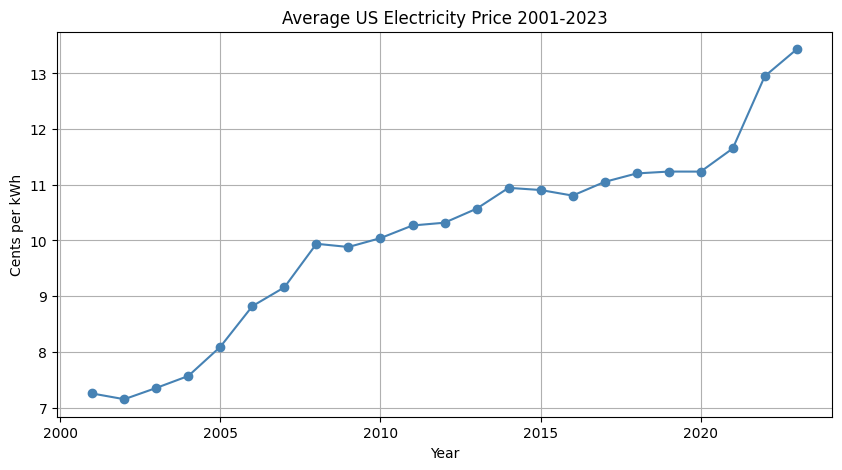

In [29]:
import matplotlib.pyplot as plt

# Average electricity price over time across all states
df_price_trend = df_master.groupby('year')['price'].mean()

plt.figure(figsize=(10,5))
plt.plot(df_price_trend.index, df_price_trend.values, marker='o', color='steelblue')
plt.title("Average US Electricity Price 2001-2023")
plt.xlabel("Year")
plt.ylabel("Cents per kWh")
plt.grid(True)
plt.show()

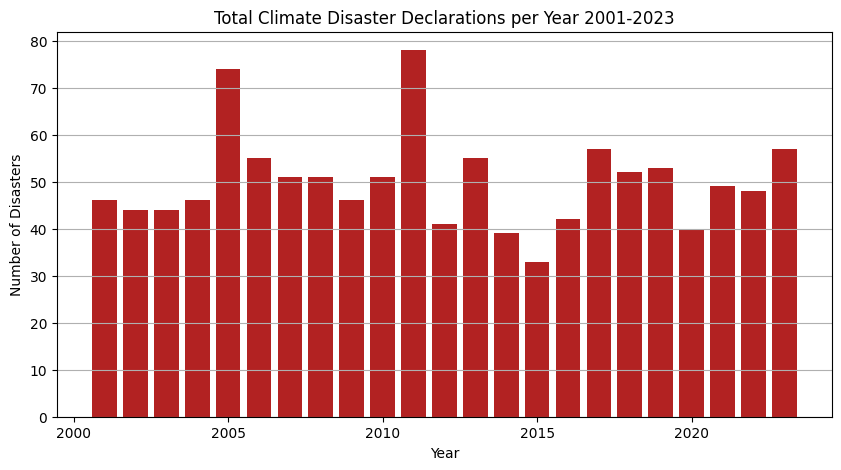

In [30]:
# Total climate disasters per year across all states
df_disaster_trend = df_master.groupby('year')['disaster_count'].sum()

plt.figure(figsize=(10,5))
plt.bar(df_disaster_trend.index, df_disaster_trend.values, color='firebrick')
plt.title("Total Climate Disaster Declarations per Year 2001-2023")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.grid(True, axis='y')
plt.show()


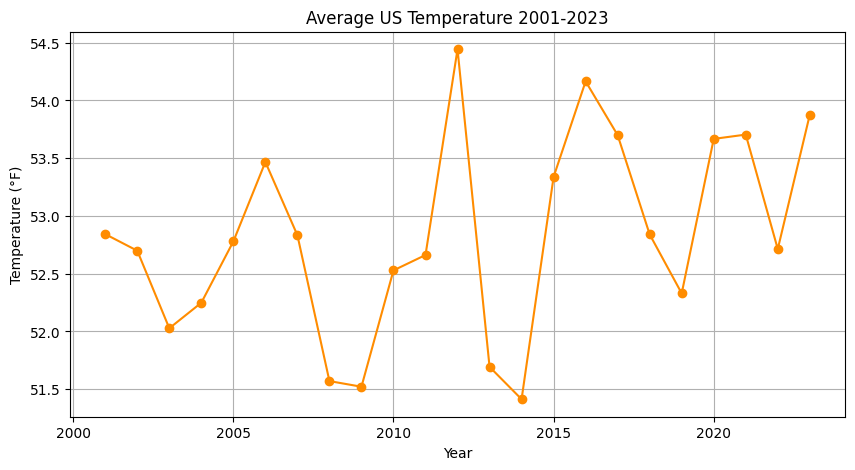

In [31]:
# Average US temperature over time
df_temp_trend = df_master.groupby('year')['avg_temp'].mean()

plt.figure(figsize=(10,5))
plt.plot(df_temp_trend.index, df_temp_trend.values, marker='o', color='darkorange')
plt.title("Average US Temperature 2001-2023")
plt.xlabel("Year")
plt.ylabel("Temperature (°F)")
plt.grid(True)
plt.show()
